# 07 — Out-of-Sample Validation: Big Sur / Central Coast

**Bbox:** 34.8–36.0°N, 122.5–120.5°W  
**Why this region:** Sits between MidCal and SoCal boxes. Never used in model building.  
**Question:** Do the same EWS signals (rising AR1 + variance before collapse) appear here,  
using a model built entirely on the other 3 regions?

Pipeline is identical to notebooks 00–06. No new methods.

In [1]:
# ============================================================
# CELL 1: EXTRACT KELP FROM NETCDF (same fast run-mode as 00)
# ============================================================
import numpy as np
import pandas as pd
from netCDF4 import Dataset, num2date
from pathlib import Path
import time

# --- paths ---
DATA_PATH = "/Users/tonylin/Documents/kelp_project/1_DATA/raw/LandsatKelpBiomass_2025_Q3_v2_withmetadata.nc"
OUT_DIR   = Path("/Users/tonylin/Documents/kelp_project/1_DATA/processed/bigsur")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Big Sur / Central Coast bbox ---
lat_min, lat_max =  34.8,  36.0
lon_min, lon_max = -122.5, -120.5

MIN_COV_FRAC = 0.2
BLOCK_SIZE   = 100_000
PRINT_EVERY  = 50

t0 = time.time()

with Dataset(DATA_PATH, "r") as nc:
    lat = nc.variables["latitude"][:]
    lon = nc.variables["longitude"][:]

    if np.nanmax(lon) > 180:
        lon = ((lon + 180) % 360) - 180

    bbox_mask = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
    bbox_idx  = np.flatnonzero(bbox_mask).astype(np.int64)
    N_PIX     = int(bbox_idx.size)

    print(f"Total stations: {lat.shape[0]}")
    print(f"Stations in Big Sur bbox: {N_PIX}")
    if N_PIX == 0:
        raise ValueError("No kelp pixels found — check lat/lon ranges")

    tvar       = nc.variables["time"]
    cal        = getattr(tvar, "calendar", "standard")
    time_vals  = num2date(tvar[:], units=tvar.units, calendar=cal)
    try:
        time_index = pd.to_datetime(time_vals)
    except Exception:
        time_index = pd.to_datetime([str(t) for t in time_vals])
    ntime = time_index.size

    area = nc.variables["area"]
    try:
        area.set_auto_maskandscale(False)
    except Exception:
        pass
    fill = getattr(area, "_FillValue", None) or getattr(area, "missing_value", None)

    total    = np.zeros(ntime, dtype=np.float64)
    coverage = np.zeros(ntime, dtype=np.int64)

    d       = np.diff(bbox_idx)
    breaks  = np.where(d != 1)[0]
    r_start = np.r_[bbox_idx[0], bbox_idx[breaks + 1]]
    r_end   = np.r_[bbox_idx[breaks] + 1, bbox_idx[-1] + 1]
    n_runs  = len(r_start)

    print(f"Contiguous runs: {n_runs}")

    if n_runs <= 5000:
        print("Using RUN-MODE")
        for i, (s, e) in enumerate(zip(r_start, r_end), 1):
            block = np.array(area[:, s:e], dtype=np.float32)
            valid = np.isfinite(block)
            if fill is not None:
                valid &= (block != fill)
            block[~valid] = 0.0
            total    += block.sum(axis=1)
            coverage += valid.sum(axis=1).astype(np.int64)
            if i % PRINT_EVERY == 0 or i == n_runs:
                print(f"  runs {i}/{n_runs} | elapsed {time.time()-t0:.1f}s")
    else:
        print("Using BLOCK-SCAN fallback")
        nstations  = lat.shape[0]
        bbox_total = int(bbox_mask.sum())
        bbox_done  = 0
        for start in range(0, nstations, BLOCK_SIZE):
            end = min(start + BLOCK_SIZE, nstations)
            m   = bbox_mask[start:end]
            if not m.any():
                continue
            block = np.array(area[:, start:end], dtype=np.float32)
            valid = np.isfinite(block)
            if fill is not None:
                valid &= (block != fill)
            block = block[:, m]; valid = valid[:, m]
            block[~valid] = 0.0
            total    += block.sum(axis=1)
            coverage += valid.sum(axis=1).astype(np.int64)
            bbox_done += int(m.sum())
            print(f"  {bbox_done}/{bbox_total} | elapsed {time.time()-t0:.1f}s")

# build df
kelp_area     = total.astype(np.float64)
coverage_frac = coverage / N_PIX
kelp_area[coverage == 0]                  = np.nan
kelp_area[coverage_frac < MIN_COV_FRAC]   = np.nan

df_kelp = pd.DataFrame({
    "kelp_area":     kelp_area,
    "coverage":      coverage,
    "coverage_frac": coverage_frac,
}, index=time_index).sort_index()

df_kelp["kelp_smooth"] = df_kelp["kelp_area"].rolling(4, center=True, min_periods=2).mean()

out_csv = OUT_DIR / "kelp_timeseries_bigsur_bbox.csv"
df_kelp.to_csv(out_csv)
print(f"\nDone. Rows: {len(df_kelp)} | saved to {out_csv}")
print(df_kelp.dropna(subset=['kelp_area']).head())

Total stations: 594107
Stations in Big Sur bbox: 47217
Contiguous runs: 6
Using RUN-MODE
  runs 6/6 | elapsed 0.6s

Done. Rows: 167 | saved to /Users/tonylin/Documents/kelp_project/1_DATA/processed/bigsur/kelp_timeseries_bigsur_bbox.csv
             kelp_area  coverage  coverage_frac   kelp_smooth
1984-05-15   1325101.0     46302       0.980621  1.730186e+06
1984-08-15   2135270.0     40689       0.861745  1.375079e+06
1984-11-15    664867.0     46685       0.988733  1.056555e+06
1985-02-15    100981.0     46679       0.988606  3.306274e+06
1985-05-15  10323980.0     40701       0.861999  5.614594e+06


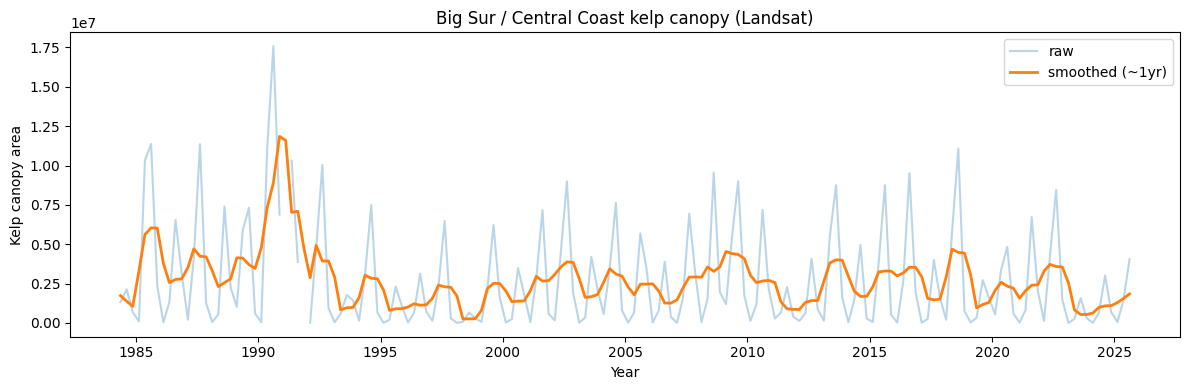

Non-NaN quarters: 164
Coverage frac mean: 0.95


In [2]:
# ============================================================
# CELL 2: QUICK PLOT — does this region have kelp?
# ============================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_kelp.index, df_kelp["kelp_area"],   alpha=0.3, label="raw")
ax.plot(df_kelp.index, df_kelp["kelp_smooth"],  linewidth=2, label="smoothed (~1yr)")
ax.set_title("Big Sur / Central Coast kelp canopy (Landsat)")
ax.set_ylabel("Kelp canopy area")
ax.set_xlabel("Year")
ax.legend()
fig.tight_layout()
plt.show()

print("Non-NaN quarters:", df_kelp["kelp_area"].notna().sum())
print("Coverage frac mean:", df_kelp["coverage_frac"].mean().round(3))

In [3]:
# ============================================================
# CELL 3: SST EXTRACTION (same OPeNDAP method as 01)
# ============================================================
import xarray as xr

lat_min, lat_max =  34.8,  36.0
lon_min, lon_max = -122.5, -120.5

url = "https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.oisst.v2.highres/sst.mon.mean.nc"
ds  = xr.open_dataset(url)

lat_name  = "lat"  if "lat"  in ds.coords else "latitude"
lon_name  = "lon"  if "lon"  in ds.coords else "longitude"

lon = ds[lon_name]
if float(lon.max()) > 180:
    lon_min_use = (lon_min + 360) % 360
    lon_max_use = (lon_max + 360) % 360
else:
    lon_min_use, lon_max_use = lon_min, lon_max

sst = ds["sst"]
sst_bbox = sst.sel({lat_name: slice(lat_min, lat_max), lon_name: slice(lon_min_use, lon_max_use)})
if sst_bbox.sizes.get(lat_name, 0) == 0:
    sst_bbox = sst.sel({lat_name: slice(lat_max, lat_min), lon_name: slice(lon_min_use, lon_max_use)})

sst_m = sst_bbox.mean(dim=[lat_name, lon_name], skipna=True).to_series()
sst_m.index = pd.to_datetime(sst_m.index)
sst_m = sst_m.sort_index()
sst_m.name = "sst"

# anomaly vs 1991-2020 climatology
baseline = sst_m.loc["1991":"2020"]
clim     = baseline.groupby(baseline.index.month).mean()
sst_anom = sst_m - sst_m.index.month.map(clim)

df_sst_m = pd.DataFrame({"sst": sst_m, "sst_anom": sst_anom})

sst_out = OUT_DIR / "oisst_bigsur_bbox_monthly.csv"
df_sst_m.to_csv(sst_out)
print("SST saved:", sst_out)
print(df_sst_m.tail())

SST saved: /Users/tonylin/Documents/kelp_project/1_DATA/processed/bigsur/oisst_bigsur_bbox_monthly.csv
                  sst  sst_anom
time                           
2025-09-01  17.470951  1.561090
2025-10-01  16.685123  1.060774
2025-11-01  15.600185  0.819734
2025-12-01  15.462580  1.747717
2026-01-01  14.895579  1.693601


In [4]:
# ============================================================
# CELL 4: BUILD SST QUARTERLY FEATURES (same as 01)
# ============================================================
kelp_times  = pd.DatetimeIndex(df_kelp.index)
kelp_qstart = kelp_times.to_period("Q").to_timestamp(how="start")

q = df_sst_m.resample("QS")

feat = pd.DataFrame({
    "sst_q_mean":     q["sst"].mean(),
    "sstanom_q_mean": q["sst_anom"].mean(),
    "sstanom_q_max":  q["sst_anom"].max(),
    "sstanom_pos_sum": q["sst_anom"].apply(lambda x: x[x > 0].sum()),
})
feat["sstanom_q_mean_lag1"] = feat["sstanom_q_mean"].shift(1)
feat["sstanom_q_max_lag1"]  = feat["sstanom_q_max"].shift(1)

feat = feat.reindex(kelp_qstart)
feat.index = kelp_times

sst_feat_out = OUT_DIR / "oisst_features_bigsur_quarterly.csv"
feat.to_csv(sst_feat_out)
print("SST features saved:", sst_feat_out)
print(feat.head(10))

SST features saved: /Users/tonylin/Documents/kelp_project/1_DATA/processed/bigsur/oisst_features_bigsur_quarterly.csv
            sst_q_mean  sstanom_q_mean  sstanom_q_max  sstanom_pos_sum  \
1984-02-15   13.584270        0.475827       0.759643         1.427482   
1984-05-15   12.441932       -0.693067      -0.416550         0.000000   
1984-08-15   16.770927        1.348598       1.934951         4.045793   
1984-11-15   14.702701       -0.003854       0.337748         0.337748   
1985-02-15   12.681520       -0.426923       0.096257         0.096257   
1985-05-15   13.006305       -0.128694       0.612342         0.612342   
1985-08-15   15.610791        0.188462       0.467319         0.629045   
1985-11-15   14.079412       -0.627143       0.073553         0.073553   
1986-02-15   13.832229        0.723786       0.932302         2.171358   
1986-05-15   13.562221        0.427222       0.886646         1.529888   

            sstanom_q_mean_lag1  sstanom_q_max_lag1  
1984-02-15   

In [5]:
# ============================================================
# CELL 5: UPWELLING (same ERDDAP method as 05)
# Big Sur ~ 35N 122W → erdUI36mo is the closest ERDDAP dataset
# ============================================================
import re

def download_upwelling_erddap(dataset_id, out_csv):
    url = f"https://coastwatch.pfeg.noaa.gov/erddap/griddap/{dataset_id}.csvp?upwelling_index,upwelling_index_anomaly"
    df  = pd.read_csv(url)
    df.columns = [re.sub(r"\s*\(.*\)$", "", c).strip() for c in df.columns]
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time").sort_index()
    df = df.rename(columns={"upwelling_index": "ui", "upwelling_index_anomaly": "ui_anom"})
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    df[["ui", "ui_anom"]].to_csv(out_csv)
    print("Upwelling saved:", out_csv, "| rows:", len(df))
    return df[["ui", "ui_anom"]]

ui_raw = download_upwelling_erddap("erdUI36mo", OUT_DIR / "upwelling_bigsur_monthly.csv")

# quarterly features
ui_raw.index = pd.to_datetime(ui_raw.index).tz_localize(None)
for c in ["ui", "ui_anom"]:
    ui_raw[c] = pd.to_numeric(ui_raw[c], errors="coerce")

uq = ui_raw.resample("QS")
ui_feat = pd.DataFrame({
    "ui_q_mean":      uq["ui"].mean(),
    "ui_q_min":       uq["ui"].min(),
    "uianom_q_mean":  uq["ui_anom"].mean(),
    "uianom_q_min":   uq["ui_anom"].min(),
})
ui_feat["uianom_q_mean_lag1"] = ui_feat["uianom_q_mean"].shift(1)
ui_feat["ui_q_mean_lag1"]     = ui_feat["ui_q_mean"].shift(1)

ui_feat = ui_feat.reindex(kelp_qstart)
ui_feat.index = kelp_times

ui_feat_out = OUT_DIR / "upwelling_features_bigsur_quarterly.csv"
ui_feat.to_csv(ui_feat_out)
print("UI features saved:", ui_feat_out)

Upwelling saved: /Users/tonylin/Documents/kelp_project/1_DATA/processed/bigsur/upwelling_bigsur_monthly.csv | rows: 960
UI features saved: /Users/tonylin/Documents/kelp_project/1_DATA/processed/bigsur/upwelling_features_bigsur_quarterly.csv


In [6]:
# ============================================================
# CELL 6: DEFINE COLLAPSE LABELS (same method as 02)
# ============================================================
# merge
df = df_kelp.join(feat, how="inner").join(ui_feat, how="left").sort_index()

# coverage quality filter
cov_thresh = 0.8 * df["coverage"].max()
df = df[df["coverage"] >= cov_thresh].copy()

# de-seasonalized robust z (same baseline as other regions)
df["q"] = df.index.quarter
baseline = df.loc["1984":"2013"]
med = baseline.groupby("q")["kelp_smooth"].median()
mad = baseline.groupby("q")["kelp_smooth"].apply(
    lambda x: np.median(np.abs(x - np.median(x))) + 1e-9
)
df["kelp_q_z"] = (df["kelp_smooth"] - df["q"].map(med)) / df["q"].map(mad)
df.drop(columns=["q"], inplace=True)

# 1-year rolling mean
df["kelp_z_1yr"] = df["kelp_q_z"].rolling(4, min_periods=4).mean()

# suppression label
base_1yr   = df.loc["1984":"2013", "kelp_z_1yr"].dropna()
sup_thresh = base_1yr.quantile(0.10)
df["suppressed"] = (df["kelp_z_1yr"] <= sup_thresh).astype(int)

# onset / offset
s = df["suppressed"]
df["onset"]  = ((s == 1) & (s.shift(1) == 0)).astype(int)
df["offset"] = ((s == 0) & (s.shift(1) == 1)).astype(int)

print("Rows after filter:", len(df))
print("Suppressed quarters:", df["suppressed"].sum())
print("Onset events:",  df["onset"].sum())
print("Recovery events:", df["offset"].sum())

# save labeled
labeled_out = OUT_DIR / "bigsur_kelp_sst_ui_labeled.csv"
df.to_csv(labeled_out)
print("Labeled table saved:", labeled_out)

Rows after filter: 158
Suppressed quarters: 16
Onset events: 4
Recovery events: 4
Labeled table saved: /Users/tonylin/Documents/kelp_project/1_DATA/processed/bigsur/bigsur_kelp_sst_ui_labeled.csv


In [7]:
# ============================================================
# CELL 7: COMPUTE EWS (identical to 06)
# ============================================================
from sklearn.metrics import roc_auc_score

ROLL_WIN = 20

z    = df["kelp_q_z"].copy()
ar1  = z.rolling(ROLL_WIN, min_periods=ROLL_WIN//2).apply(
    lambda x: pd.Series(x).autocorr(lag=1), raw=True
)
var  = z.rolling(ROLL_WIN, min_periods=ROLL_WIN//2).var()

ar1_z = (ar1 - ar1.mean()) / ar1.std()
var_z = (var - var.mean()) / var.std()
df["ews_ar1"]       = ar1
df["ews_var"]       = var
df["ews_composite"] = (ar1_z + var_z) / 2

print("EWS computed")
print(f"AR1 range:       [{ar1.min():.2f}, {ar1.max():.2f}]")
print(f"Variance range:  [{var.min():.2f}, {var.max():.2f}]")

EWS computed
AR1 range:       [0.41, 0.91]
Variance range:  [0.37, 7.62]


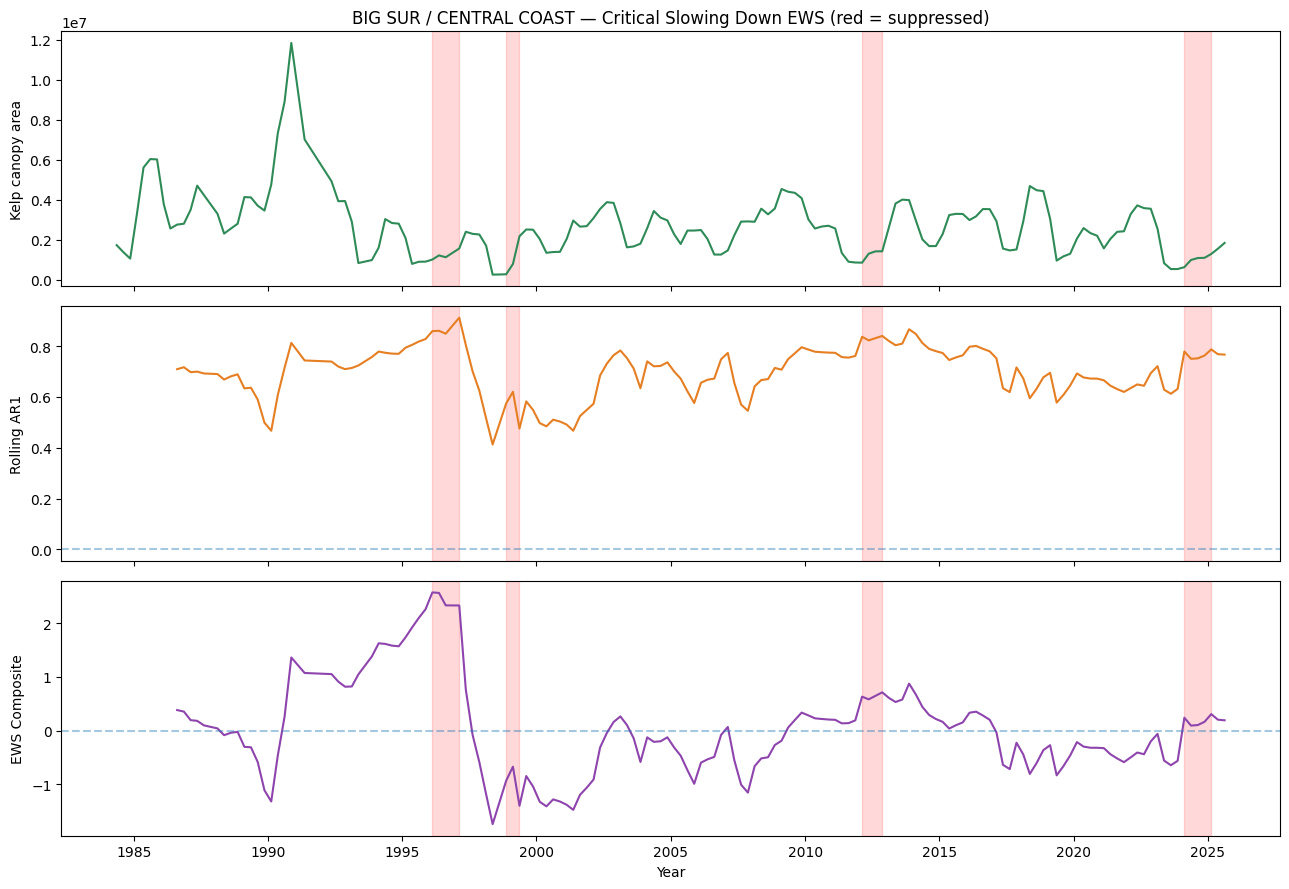

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/bigsur/bigsur_ews_overview.png


In [8]:
# ============================================================
# CELL 8: OVERVIEW PLOT (kelp + AR1 + EWS composite)
# ============================================================
from pathlib import Path
FIG_DIR = Path("/Users/tonylin/Documents/kelp_project/5_FIGURES/bigsur")
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# kelp + suppression shading
ax1.plot(df.index, df["kelp_smooth"], color="seagreen")
for _, grp in df[df["suppressed"]==1].groupby(
    (df["suppressed"] != df["suppressed"].shift()).cumsum()
):
    ax1.axvspan(grp.index[0], grp.index[-1], alpha=0.15, color="red")
ax1.set_ylabel("Kelp canopy area")
ax1.set_title("BIG SUR / CENTRAL COAST — Critical Slowing Down EWS (red = suppressed)")

# AR1
ax2.plot(df.index, df["ews_ar1"], color="#e67e22")
ax2.axhline(0, linestyle="--", alpha=0.4)
ax2.set_ylabel("Rolling AR1")
for _, grp in df[df["suppressed"]==1].groupby(
    (df["suppressed"] != df["suppressed"].shift()).cumsum()
):
    ax2.axvspan(grp.index[0], grp.index[-1], alpha=0.15, color="red")

# composite
ax3.plot(df.index, df["ews_composite"], color="#8e44ad")
ax3.axhline(0, linestyle="--", alpha=0.4)
ax3.set_ylabel("EWS Composite")
ax3.set_xlabel("Year")
for _, grp in df[df["suppressed"]==1].groupby(
    (df["suppressed"] != df["suppressed"].shift()).cumsum()
):
    ax3.axvspan(grp.index[0], grp.index[-1], alpha=0.15, color="red")

fig.tight_layout()
outpath = FIG_DIR / "bigsur_ews_overview.png"
fig.savefig(outpath, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", outpath)

In [9]:
# ============================================================
# CELL 9: BLOCK BOOTSTRAP HELPER
# ============================================================
def block_bootstrap_auc(score, y, block_len=4, B=3000, seed=42):
    score = np.asarray(score, dtype=float)
    y     = np.asarray(y, dtype=int)
    n     = len(y)
    starts   = np.arange(0, n - block_len + 1)
    n_blocks = int(np.ceil(n / block_len))
    rng      = np.random.default_rng(seed)

    aucs, diffs = [], []
    for _ in range(B):
        chosen = rng.choice(starts, size=n_blocks, replace=True)
        idx    = np.concatenate([np.arange(s, s + block_len) for s in chosen])[:n]
        sb, yb = score[idx], y[idx]
        if np.unique(yb).size < 2:
            continue
        aucs.append(roc_auc_score(yb, sb))
        diffs.append(sb[yb==1].mean() - sb[yb==0].mean())

    aucs  = np.array(aucs)
    diffs = np.array(diffs)
    return {
        "auc":     aucs.mean(),
        "auc_ci":  np.quantile(aucs,  [0.025, 0.975]),
        "diff":    diffs.mean(),
        "diff_ci": np.quantile(diffs, [0.025, 0.975]),
        "n":       len(aucs)
    }

print("Helper ready")

Helper ready


In [10]:
# ============================================================
# CELL 10: EWS AUC BY LEAD TIME
# ============================================================
y = df["onset"].astype(int)
print(f"Onset events: {y.sum()} / {len(y)} quarters")
print()

rows = []
for lead in range(1, 7):
    score = df["ews_composite"].shift(lead)
    tmp   = pd.DataFrame({"s": score, "y": y}).dropna()
    if tmp["y"].sum() < 2:
        print(f"lead={lead}q: not enough onset events (n={tmp['y'].sum()})")
        continue
    out = block_bootstrap_auc(tmp["s"], tmp["y"], block_len=4, B=3000, seed=42)
    sig = "✓ SIGNIFICANT" if out["auc_ci"][0] > 0.5 else ""
    print(f"lead={lead}q | n={len(tmp)} onset={tmp['y'].sum()} "
          f"| AUC={out['auc']:.3f} CI=[{out['auc_ci'][0]:.3f},{out['auc_ci'][1]:.3f}] {sig}")
    rows.append({"lead": lead, "auc": out["auc"],
                 "ci_lo": out["auc_ci"][0], "ci_hi": out["auc_ci"][1]})

res_bigsur = pd.DataFrame(rows)

Onset events: 4 / 158 quarters

lead=1q | n=148 onset=4 | AUC=0.461 CI=[0.000,0.900] 
lead=2q | n=147 onset=4 | AUC=0.449 CI=[0.077,0.883] 
lead=3q | n=146 onset=4 | AUC=0.507 CI=[0.207,0.893] 
lead=4q | n=145 onset=4 | AUC=0.669 CI=[0.469,0.909] 
lead=5q | n=144 onset=4 | AUC=0.733 CI=[0.524,0.919] ✓ SIGNIFICANT
lead=6q | n=143 onset=4 | AUC=0.742 CI=[0.445,0.972] 


In [11]:
# ============================================================
# CELL 11: MODEL COMPARISON TABLE
# ============================================================
from sklearn.linear_model import LogisticRegression

HEAT_LAG = 4
best_lead = int(res_bigsur.sort_values("auc", ascending=False).iloc[0]["lead"]) if not res_bigsur.empty else 1

heat    = df["sstanom_q_max"].shift(HEAT_LAG)
ews     = df["ews_composite"].shift(best_lead)
persist = df["suppressed"].shift(1).astype(float)

cdf = pd.DataFrame({"y": y, "heat": heat, "ews": ews, "persist": persist}).dropna()
Y   = cdf["y"].values

print(f"BIG SUR | onset events: {Y.sum()} / {len(Y)}")
print(f"Best EWS lead: {best_lead} quarters")
print()

for label, cols in [
    ("Persistence (baseline)",  ["persist"]),
    ("SST heat only (lag 4q)",  ["heat"]),
    ("EWS only",                ["ews"]),
    ("SST + EWS combined",      ["heat", "ews"]),
]:
    X = cdf[cols].values
    if X.shape[1] == 1:
        score = X[:, 0]
    else:
        Xs = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-9)
        m  = LogisticRegression(class_weight="balanced", max_iter=500)
        m.fit(Xs, Y)
        score = m.predict_proba(Xs)[:, 1]

    if len(np.unique(Y)) < 2:
        print(f"  {label}: cannot compute AUC (only one class)")
        continue

    out = block_bootstrap_auc(score, Y, block_len=4, B=3000, seed=42)
    sig = "✓ SIGNIFICANT" if out["auc_ci"][0] > 0.5 else ""
    print(f"  {label:35s} AUC={out['auc']:.3f} "
          f"CI=[{out['auc_ci'][0]:.3f},{out['auc_ci'][1]:.3f}] {sig}")

BIG SUR | onset events: 4 / 143
Best EWS lead: 6 quarters

  Persistence (baseline)              AUC=0.444 CI=[0.396,0.482] 
  SST heat only (lag 4q)              AUC=0.568 CI=[0.151,0.950] 
  EWS only                            AUC=0.742 CI=[0.445,0.972] 
  SST + EWS combined                  AUC=0.777 CI=[0.552,0.951] ✓ SIGNIFICANT


Onset events available for trajectory: 4


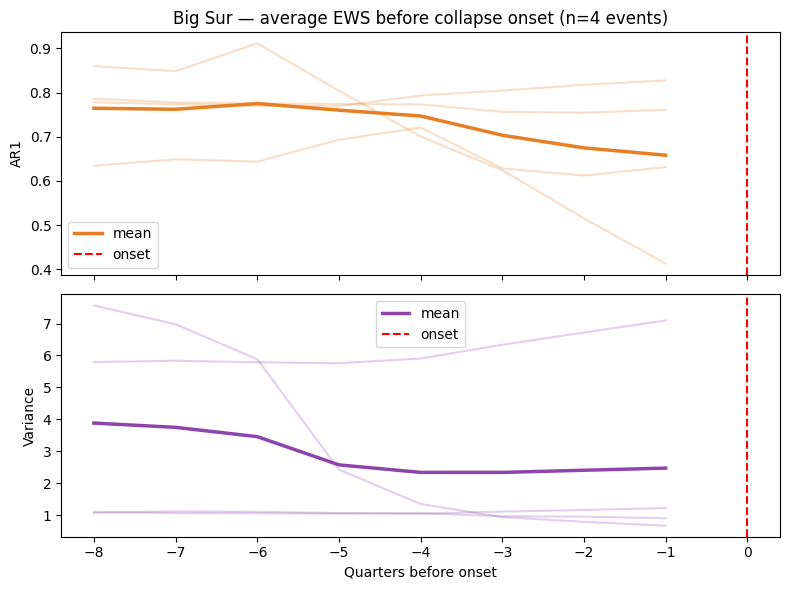

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/bigsur/bigsur_ews_pre_onset_trajectory.png


In [12]:
# ============================================================
# CELL 12: PRE-ONSET TRAJECTORY PLOT
# ============================================================
WINDOW_BEFORE = 8
onset_times   = df.index[df["onset"] == 1]

print(f"Onset events available for trajectory: {len(onset_times)}")

traces_ar1, traces_var = [], []
for t in onset_times:
    loc   = df.index.get_loc(t)
    start = loc - WINDOW_BEFORE
    if start < 0:
        continue
    window = df.iloc[start:loc]
    if len(window) < WINDOW_BEFORE:
        continue
    traces_ar1.append(window["ews_ar1"].values)
    traces_var.append(window["ews_var"].values)

if traces_ar1:
    ar1_m = np.nanmean(traces_ar1, axis=0)
    var_m = np.nanmean(traces_var, axis=0)
    x     = np.arange(-WINDOW_BEFORE, 0)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    for tr in traces_ar1:
        ax1.plot(x, tr, alpha=0.25, color="#e67e22")
    ax1.plot(x, ar1_m, color="#e67e22", linewidth=2.5, label="mean")
    ax1.axvline(0, linestyle="--", color="red", label="onset")
    ax1.set_ylabel("AR1")
    ax1.set_title(f"Big Sur — average EWS before collapse onset (n={len(traces_ar1)} events)")
    ax1.legend()

    for tr in traces_var:
        ax2.plot(x, tr, alpha=0.25, color="#8e44ad")
    ax2.plot(x, var_m, color="#8e44ad", linewidth=2.5, label="mean")
    ax2.axvline(0, linestyle="--", color="red", label="onset")
    ax2.set_ylabel("Variance")
    ax2.set_xlabel("Quarters before onset")
    ax2.legend()

    fig.tight_layout()
    outpath = FIG_DIR / "bigsur_ews_pre_onset_trajectory.png"
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", outpath)
else:
    print("Not enough onset events for trajectory plot.")

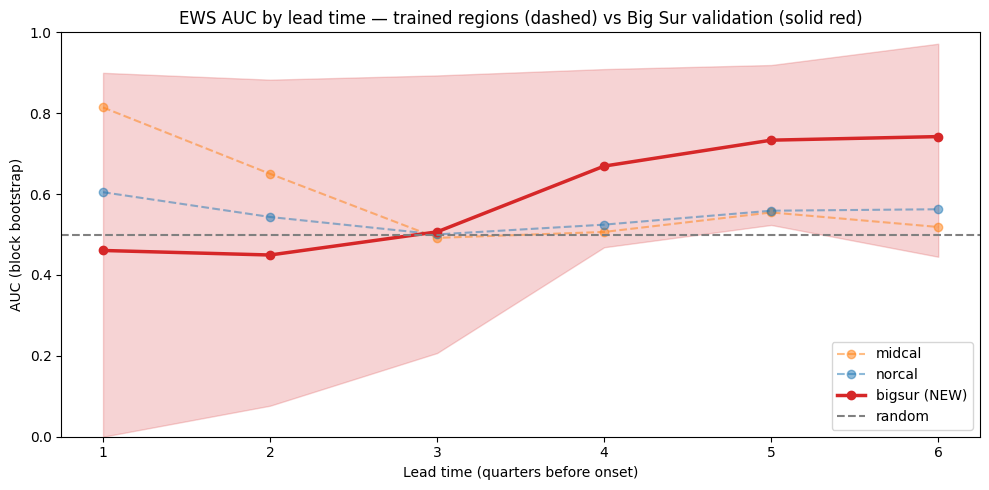

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/bigsur/bigsur_vs_trained_regions_auc.png


In [13]:
# ============================================================
# CELL 13: COMPARE BIG SUR vs TRAINED REGIONS
# ============================================================
# Pull in your saved results from notebook 06 and compare

trained_csv = Path("/Users/tonylin/Documents/kelp_project/1_DATA/processed/ews_onset_auc_results.csv")

if trained_csv.exists():
    trained = pd.read_csv(trained_csv)
    bigsur_res = res_bigsur.copy()
    bigsur_res["region"] = "bigsur"

    colors = {"norcal": "#1f77b4", "midcal": "#ff7f0e",
              "socal": "#2ca02c",  "bigsur": "#d62728"}

    fig, ax = plt.subplots(figsize=(10, 5))

    for region, sub in trained.groupby("region"):
        c = colors.get(region, "gray")
        ax.plot(sub["lead"], sub["auc"], marker="o", label=region, color=c, alpha=0.5, linestyle="--")

    if not bigsur_res.empty:
        ax.plot(bigsur_res["lead"], bigsur_res["auc"],
                marker="o", label="bigsur (NEW)", color=colors["bigsur"], linewidth=2.5)
        ax.fill_between(bigsur_res["lead"], bigsur_res["ci_lo"], bigsur_res["ci_hi"],
                        alpha=0.2, color=colors["bigsur"])

    ax.axhline(0.5, linestyle="--", color="gray", label="random")
    ax.set_xlabel("Lead time (quarters before onset)")
    ax.set_ylabel("AUC (block bootstrap)")
    ax.set_title("EWS AUC by lead time — trained regions (dashed) vs Big Sur validation (solid red)")
    ax.legend()
    ax.set_ylim(0, 1)
    fig.tight_layout()

    outpath = FIG_DIR / "bigsur_vs_trained_regions_auc.png"
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", outpath)
else:
    print("trained results CSV not found — run notebook 06 first")
    print("Showing Big Sur results only:")
    print(res_bigsur)

## How to interpret this for ISEF

**If Big Sur EWS AUC > 0.5 with CI above 0.5:**
> "We validated our early-warning signal in a completely held-out region —
> the Big Sur / Central Coast kelp bed — that was never used to build the model.
> The signal remained significant, suggesting Critical Slowing Down is a general
> property of California kelp collapse, not an artifact of our training data."

**If Big Sur results are weaker / not significant:**
> "Out-of-sample validation in the Big Sur region showed weaker EWS signal,
> which may reflect differences in local oceanography, disturbance history,
> or fewer collapse events available for testing. This highlights that EWS
> skill may be region-specific — itself an important finding for conservation monitoring."

Either outcome is scientifically valid. The act of testing out-of-sample is what matters.